In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
from torch import Tensor
from torch.distributions import Distribution
import os
# --- CONSOLIDATED EPSILON ---
EPS = 1e-6 

# ======================================================================
# 1. ROBUST HELPER FUNCTIONS (Continuous Categorical Distribution)
# ======================================================================

def inv_cdf_torch(u, l):
    """
    Inverse CDF of the continuous Bernoulli distribution.
    [cite_start]Used for reparameterization in CC sampling[cite: 600].
    """
    near_half = (l > 0.499) & (l < 0.501)
    safe_l = l.clamp(EPS, 1 - EPS)
    u = u.clamp(EPS, 1 - EPS)
    
    num = torch.log(u * (2 * safe_l - 1) + 1 - safe_l) - torch.log(1 - safe_l)
    den = torch.log(safe_l) - torch.log(1 - safe_l)
    x = num / den
    return torch.where(near_half, u, x)

def sample_cc_ordered_reparam(lam):
    """
    [cite_start]Ordered Rejection Sampler (Algorithm 1 in the CC paper [cite: 164]).
    Sorts lambda (lam) to maximize acceptance rate.
    lam: [B, K]
    Returns: [B, K] sample on the simplex.
    """
    B, K = lam.shape
    
    # 1. Sort lambda descending (largest to smallest)
    lam_sorted, indices = torch.sort(lam, dim=1, descending=True)
    
    # 2. Prepare Parameters (CB params = lam_i / (lam_i + lam_1))
    lam_1 = lam_sorted[:, 0].unsqueeze(1) 
    lam_rest = lam_sorted[:, 1:] 
    
    cb_params = lam_rest / (lam_rest + lam_1 + EPS)

    final_x_rest = torch.zeros_like(lam_rest)
    active_mask = torch.ones(B, dtype=torch.bool, device=lam.device)
    max_attempts = 1000 
    
    for _ in range(max_attempts):
        if not active_mask.any():
            break
        
        n_active = active_mask.sum()
        u = torch.rand(n_active, K-1, device=lam.device, dtype=lam.dtype)
        
        active_params = cb_params[active_mask]
        # 4. Inverse CDF (Differentiable)
        x_cand = inv_cdf_torch(u, active_params) 
        
        # 5. Check constraint (Sum <= 1)
        sums = x_cand.sum(dim=1)
        accepted_now = (sums <= 1.0)
        
        # 6. Update tensors
        active_indices = torch.nonzero(active_mask).squeeze(-1)
        accepted_indices = active_indices[accepted_now]
        
        if accepted_indices.numel() > 0:
            final_x_rest[accepted_indices] = x_cand[accepted_now]
            # Clone mask before modification to satisfy autograd
            active_mask = active_mask.clone()
            active_mask[accepted_indices] = False
            
    # 7. Calculate the Slack Variable: x_1 = 1 - sum(x_rest)
    x_1 = (1.0 - final_x_rest.sum(dim=1, keepdim=True)).clamp(min=EPS)
    x_sorted = torch.cat([x_1, final_x_rest], dim=1)
    
    # 8. Unsort back to original order
    x_final = torch.zeros_like(lam)
    x_final.scatter_(1, indices, x_sorted)
    
    return x_final

class CCDistributionUtils:
    """Container for CC log-probability and parameter conversion functions."""
    
    @staticmethod
    def lambda_to_eta(lam: Tensor) -> Tensor:
        #[cite_start]"""Converts mean parameter lambda [B, K] to natural parameter eta [B, K-1][cite: 91]."""
        lam = lam.clamp(min=EPS, max=1.0) 
        last = lam[:, -1].unsqueeze(1)
        eta = torch.log(lam / (last + EPS))
        return eta[:, :-1]

    @staticmethod
    def cc_log_norm_const_torch(eta: Tensor) -> Tensor:
        """
        [cite_start]Calculates log C(eta) using the Exact Formula (Eq 7 in the paper [cite: 124]).
        [cite_start]Note: Calculation is done in double precision for stability[cite: 134].
        """
        original_dtype = eta.dtype
        eta = eta.double()

        B, K_minus_1 = eta.shape
        K = K_minus_1 + 1
        device = eta.device
        
        # [cite_start]1. Construct full eta (append 0 for the Kth component) [cite: 92]
        eta_full = torch.cat([eta, torch.zeros(B, 1, device=device, dtype=eta.dtype)], dim=1)
        
        # 2. Add Jitter
        jitter = torch.arange(K, device=device) * 1e-5
        eta_full = eta_full + jitter.unsqueeze(0)

        # 3. Compute the denominator product: prod_{i!=k} (eta_i - eta_k) 
        eta_i = eta_full.unsqueeze(1) 
        eta_k = eta_full.unsqueeze(2)
        diffs = eta_i - eta_k
        
        eye_mask = torch.eye(K, device=device).bool().unsqueeze(0).expand(B, -1, -1)
        diffs[eye_mask] = 1.0 
        
        log_diffs_abs = diffs.abs().log()
        diffs_sign = diffs.sign()
        
        log_denom = log_diffs_abs.sum(dim=1) 
        denom_sign = diffs_sign.prod(dim=1) 
        
        log_terms_mag = eta_full - log_denom
        terms_sign = denom_sign
        
        # 4. Sum the terms: S = sum_k (T_k)
        max_log_mag, _ = log_terms_mag.max(dim=1, keepdim=True)
        sum_scaled = torch.sum(terms_sign * torch.exp(log_terms_mag - max_log_mag), dim=1)
        
        # 5. Multiply by (-1)^(K+1) 
        global_sign = (-1)**(K + 1)
        total_sum_signed = global_sign * sum_scaled
        
        log_inv_C = max_log_mag.squeeze() + torch.log(total_sum_signed.clamp(min=EPS))
        
        # Return log C = - log(C^-1)
        return -log_inv_C.to(dtype=original_dtype)

    @staticmethod
    def cc_log_prob_torch(sample: Tensor, eta: Tensor) -> Tensor:
        """
        [cite_start]Calculates the log-density p(z | eta) = eta^T * z + log C(eta)[cite: 94].
        sample: [B, K], eta: [B, K-1]
        Returns: [B]
        """
        n, K_minus_1 = eta.shape
        aug_eta = torch.cat([eta, torch.zeros(n, 1, device=eta.device, dtype=eta.dtype)], dim=-1)
        
        # Exponent term: eta^T * z
        exponent = torch.sum(sample * aug_eta, dim=1) 
        
        # Log Normalizer term
        log_norm_const = CCDistributionUtils.cc_log_norm_const_torch(eta)
        
        return exponent + log_norm_const 

# ======================================================================
# 2. MODEL DEFINITIONS
# ======================================================================

class MLPEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dims),
            nn.ReLU(),
            nn.Linear(hidden_dims, latent_dim)
        )

    def forward(self, x):
        return self.net(x)

class BernoulliDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_dims, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dims, bias=False), 
            nn.ReLU(),
            nn.Linear(hidden_dims, output_dim, bias=False)
        )

    def forward(self, z):
        return self.net(z)

class CCVAE(nn.Module):
    def __init__(self, input_dim, enc_hidden_dims, dec_hidden_dims, latent_dim):
        super().__init__()
        
        self.cc_utils = CCDistributionUtils()
        
        self.latent_dim = latent_dim
        self.encoder = MLPEncoder(input_dim, enc_hidden_dims, latent_dim)
        self.decoder = BernoulliDecoder(latent_dim, dec_hidden_dims, input_dim)

        # Set explore_epochs higher for a slower T annealing schedule
        self.explore_epochs = 100 
        self.current_epoch = 1


    def forward(self, x):
        lam_logits = self.encoder(x)
        
        # lam is the mean parameter [B, K]
        lam = F.softmax(lam_logits, dim=1)

        # Directly use the reparameterized sampler
        z = sample_cc_ordered_reparam(lam) 

        recon_logits = self.decoder(z)
        return recon_logits, lam, z

# ======================================================================
# 3. VARIATIONAL INFERENCE CLASS (The Loss Function Module with Free-Bits)
# ======================================================================

class VariationalInference(nn.Module):
    """
    Computes the beta-ELBO loss for the CCVAE based on model outputs, 
    including KL Warmup and Free-Bits regularization.
    """
    def __init__(self, cc_utils: CCDistributionUtils, zero_beta_epochs:float,  base_beta: float = 1.0, warmup_epochs: int = 100, max_beta: float = 1.0, C_free: float = 0.0):
        super().__init__()
        self.cc_utils = cc_utils
        self.zero_beta_epochs = zero_beta_epochs
        self.base_beta = base_beta
        # Use a more robust warmup period
        self.warmup_epochs = warmup_epochs
        self.max_beta = max_beta
        # C_free is the Free-Bits threshold
        self.C_free = C_free
        
    def get_beta(self, epoch: int) -> float:
        """
        Calculates the annealing beta for KL divergence using a three-stage schedule:
        1. Zero Beta (Pure Recon)
        2. Linear Ramp-up
        3. Constant Final Beta
        """
        
        if epoch <= self.zero_beta_epochs:
            # Stage 1: Zero beta (pure reconstruction phase)
            beta = 0.0
            
        elif epoch < self.zero_beta_epochs + self.warmup_epochs:
            # Stage 2: Linear ramp up
            # Calculate progress starting from the end of the zero-beta phase
            progress = (epoch - self.zero_beta_epochs) / self.warmup_epochs
            beta = self.base_beta * progress
            
        else:
            # Stage 3: Constant beta (stable phase)
            beta = self.base_beta
            
        return min(self.max_beta, beta)

    # Note: The forward method (which is not shown but assumed to be correct) 
    # must be using self.get_beta(epoch) to calculate the final loss coefficient.
    def forward(self, x: Tensor, logits_dec: Tensor, lam: Tensor, z: Tensor, epoch: int):
        K = lam.size(1) 
        
        # --- 1. Reconstruction Loss (Negative Log-Likelihood) ---
        bce = F.binary_cross_entropy_with_logits(logits_dec, x, reduction='none')
        recon_loss = bce.sum(dim=1).mean() # Mean over batch

        # --- 2. Monte Carlo KL Divergence ---
        # Posterior Parameters (eta_q) and Prior Parameters (eta_p)
        eta_q = self.cc_utils.lambda_to_eta(lam)
        prior_lam = torch.full_like(lam, 1.0 / K)
        eta_p = self.cc_utils.lambda_to_eta(prior_lam)

        # Log densities p(z|q) and p(z|p)
        log_q = self.cc_utils.cc_log_prob_torch(z, eta_q) # [B]
        log_p = self.cc_utils.cc_log_prob_torch(z, eta_p) # [B]

        # KL = E_z [log q(z) - log p(z)]
        kl = (log_q - log_p).mean() # True KL (for logging)
        
        # --- 3. Free-Bits Regularization ---
        # kl_penalty = max(KL, C_free)
        kl_penalty = torch.max(kl, torch.tensor(self.C_free, device=kl.device))
        
        # --- 4. β-ELBO Loss ---
        beta = self.get_beta(epoch)
        
        # Loss = Recon Loss + beta * KL_penalty (Minimizing the Negative ELBO)
        loss = recon_loss + beta * kl_penalty
        
        return loss, recon_loss, kl


# ==========================================
# 4. TRAINING UTILS (Loss Wrapper and Loops)
# ==========================================

def ccvae_loss(model: 'CCVAE', vi: VariationalInference, x: Tensor, epoch: int):
    """Performs model forward pass and uses VI module to calculate loss."""
    logits_dec, lam, z = model(x) 
    loss, recon_loss, kl = vi(x, logits_dec, lam, z, epoch)
    return loss, recon_loss, kl, z

def train_loop(model: 'CCVAE', vi: VariationalInference, optimizer, train_loader, device):
    model.train()
    tot_loss = 0.0
    tot_recon = 0.0
    tot_kl = 0.0
    n_samples = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        
        loss, recon, kl, _ = ccvae_loss(model, vi, x, model.current_epoch)
        
        loss.backward()
        optimizer.step()
        
        batch_size = x.size(0)
        tot_loss += loss.item() * batch_size
        tot_recon += recon.item() * batch_size
        tot_kl += kl.item() * batch_size
        n_samples += batch_size

    mean_loss = tot_loss / n_samples
    mean_recon = tot_recon / n_samples
    mean_kl = tot_kl / n_samples
    print(f"Negative ELBO: {mean_loss:.4f} | Recon Loss: {mean_recon:.4f} | KL: {mean_kl:.4f}")
    return mean_loss, mean_recon, mean_kl

def test_loop(model: 'CCVAE', vi: VariationalInference, test_loader, device):
    model.eval()
    tot_loss = 0.0
    tot_recon = 0.0
    tot_kl = 0.0
    n_samples = 0
    with torch.no_grad():
        for x, label in test_loader:
            x = x.to(device)
            loss, recon, kl, z = ccvae_loss(model, vi, x, model.current_epoch)
            b = x.size(0)
            tot_loss += loss.item() * b
            tot_recon += recon.item() * b
            tot_kl += kl.item() * b
            n_samples += b

    mean_loss = tot_loss / n_samples
    mean_recon = tot_recon / n_samples
    mean_kl = tot_kl / n_samples
    print(f"Negative ELBO: {mean_loss:.4f} | Recon Loss: {mean_recon:.4f} | KL: {mean_kl:.4f}")
    return mean_loss, mean_recon, mean_kl

def train_from_scratch(model: 'CCVAE',vi:VariationalInference, train_loader, test_loader, device):
    # Instantiate the VariationalInference module with Free-Bits and a longer Warmup
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    # Increase the training duration significantly if you were only running 50 epochs before
    for epoch in range(1, 71): # Run for 150 epochs
        model.current_epoch = epoch
        print(f"Epoch {epoch}")
        print("--------")
        train_loop(model, vi, optimizer, train_loader, device) 
        print("")
        
        if epoch % 5 == 0:
            test_loop(model, vi, test_loader, device) 
            model.eval()
            with torch.no_grad():
                batch, _ = next(iter(test_loader))
                batch = batch[:16].to(device)
                logits_dec, _, _ = model(batch)
                recon_imgs = torch.sigmoid(logits_dec).view(-1, 1, 28, 28)
                comparison = torch.cat([batch.view(-1, 1, 28, 28), recon_imgs])

                os.makedirs("saves/CCVAE/recon_images", exist_ok=True)
                torchvision.utils.save_image(
                    comparison,
                    f"saves/CCVAE/recon_images/recon_test_epoch_{epoch:02d}.png",
                    nrow=16
                )
    return model

In [7]:
if __name__ == "__main__":

    if torch.cuda.is_available():
        device = torch.device("cuda")
    #### IMPORTANT, the torch.gamma and torch.digamma explode when using mps (floating point errors)
    #  elif torch.backends.mps.is_available():
    #  device = torch.device("mps")
    else:
        device = torch.device("cpu")

    print("Current device:", device)
        
    # Simple binarization transform
    transform = T.Compose([
    T.ToTensor(), 
    lambda t: t.view(-1) 
        ])
    trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    def filter_mnist(dataset, keep):
        mask = torch.isin(dataset.targets, torch.tensor(keep))
        dataset.data = dataset.data[mask]
        dataset.targets = dataset.targets[mask]
        return dataset

    # Filter for digits 1, 2, and 3
    trainset = filter_mnist(trainset, keep=[1,2,4])
    testset = filter_mnist(testset, keep=[1,2,4])
    train_loader = DataLoader(trainset, batch_size=100, shuffle=True, num_workers=0)
    test_loader = DataLoader(testset, batch_size=100, shuffle=True, num_workers = 0)

    input_dim = 28 * 28
    latent_dim = 3

    model = CCVAE(input_dim=input_dim,
                  enc_hidden_dims=500,
                  dec_hidden_dims=500,
                  latent_dim=latent_dim).to(device)

    vi = VariationalInference(
        cc_utils=model.cc_utils, 
        zero_beta_epochs = 20,
        base_beta=0.1, 
        warmup_epochs=40, # Matches setting from train_from_scratch
        max_beta=1.0, 
        C_free=10.0         # Matches setting from train_from_scratch (Free-Bits)
    ).to(device)
        # Check if trained model exists
    if os.path.exists(f"saves/CCVAE/CCVAE_checkpoint_{latent_dim}.pth"):
        model.load_state_dict(torch.load(f"saves/CCVAE/CCVAE_checkpoint_{latent_dim}.pth", weights_only=True, map_location=device))
    else:
        model = train_from_scratch(model, vi, train_loader, test_loader, device)
        torch.save(model.state_dict(), f"saves/CCVAE/CCVAE_checkpoint_{latent_dim}.pth")

    # Instantiate the VariationalInference module with the training hyperparameters
    print("-------------")
    print("Test Results:")
    # Pass the VI object to test_loop
    mean_test_loss, mean_test_recon, mean_test_kl = test_loop(model, vi, test_loader, device)
    
    #montecarlo_nll(model, test_loader, device, K=500)

Current device: cpu
-------------
Test Results:
Negative ELBO: 168.1077 | Recon Loss: 168.1077 | KL: 11.7119


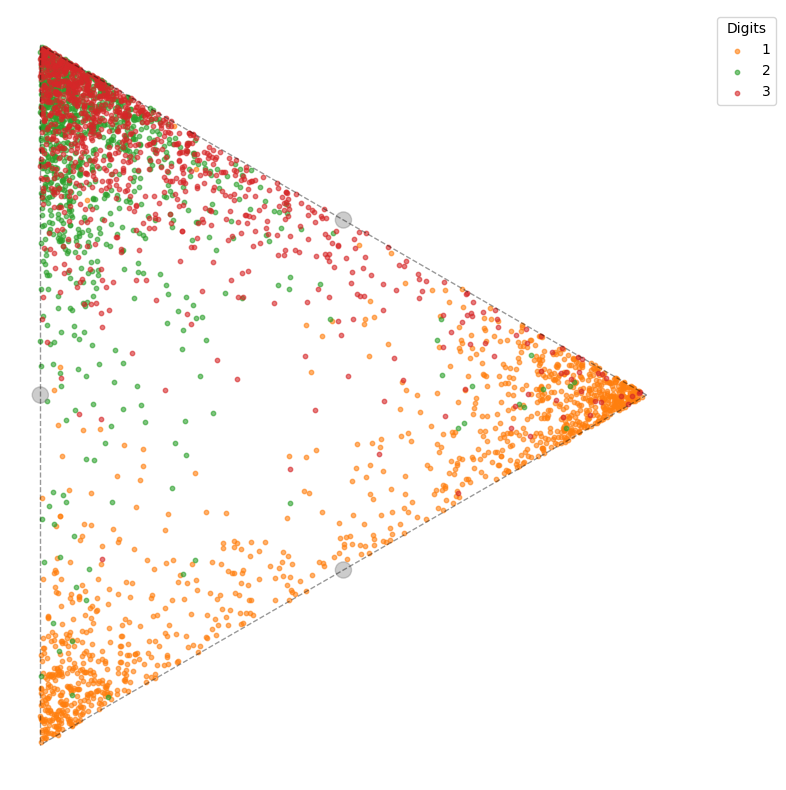

In [6]:
from plots.simplex import plot_mnist_simplex
import numpy as np
import torch
# Assuming test_loader, model, and device are defined

latents = []
labels = []

for x, y in test_loader:
    x = x.to(device)
    with torch.no_grad():
        # FIX: Model returns (recon_logits, lam, z) for the CCVAE
        # The return values are now unpacked correctly.
        recon_logits, lam, z = model(x) 
        
    # We save the CC latent sample (z) and the true labels (y)
    latents.append(z.cpu().numpy())
    labels.append(y.numpy())

latent_matrix = np.vstack(latents)
labels = np.hstack(labels)

# Assuming latent_dim (K) is correctly set to 3 or 4
plot_mnist_simplex(latent_matrix, labels, latent_dim)